# Exercise: Modeling a Harmonic Oscillator with MLP and GAN

**Course:** Deep Learning  
**Submission format:** A single executed Jupyter Notebook (`.ipynb`) with all outputs visible  




---

## Objective

In this exercise, you will explore the capabilities and limitations of two types of neural networks—**MLP (Multilayer Perceptron)** and **GAN (Generative Adversarial Network)**—for learning the **1D damped harmonic oscillator** solution.

You will train each model on a **subset** of the domain and evaluate it on the **full domain** to observe how well they generalize beyond the training region.

---

## Problem Description

The **1D damped harmonic oscillator** is governed by:

$$
m \frac{d^2 x}{d t^2} + \mu \frac{d x}{d t} + kx = 0
$$

with initial conditions:

$$
x(0) = 1, \quad \frac{dx}{dt}(0) = 0
$$

We use the **under-damped** case with parameters:

- Damping coefficient: $\delta = 2$
- Natural frequency: $\omega_0 = 20$

The exact analytical solution is:

$$
x(t) = e^{-\delta t} \left( 2A \cos(\phi + \omega t) \right)
$$

where $\omega = \sqrt{\omega_0^2 - \delta^2}$ and $A$, $\phi$ are constants determined by initial conditions.

The domain is $t \in [0, 1]$.

---

## Task Overview

You will complete **two separate training tasks**:

### Task 1: MLP (Standard Neural Network)
Train a fully connected network (provided in the starter code) to fit the harmonic oscillator solution using **only the first half** of the time domain as training data. Then evaluate on the **full domain** and analyze results.

### Task 2: GAN
Train a GAN (generator + discriminator) on the same problem, using the **first half** of the domain for training. Evaluate the generator on the **full domain** and compare performance with the MLP.

---

## Starter Code and Data Setup

Run the following setup cells in your notebook.

### Cell 1: Imports and analytical solution

HARMONIC OSCILLATOR PROBLEM
Parameters: delta = 2.0, omega_0 = 20.0
Full domain: t ∈ [0, 1] (500 points) - used for TESTING
Training domain: t ∈ [0, 0.5] (250 points)
Test domain: t ∈ (0.5, 1] (250 points)

----------------------------------------------------------------------
TRAINING DATA: 50 uniformly spaced points from t ∈ [0, 0.5]
----------------------------------------------------------------------
t range: [0.000, 0.499]
x range: [-0.726, 1.000]
Both MLP and GAN will use these 50 points for training.

First 10 training points (t, x(t)):
   1: t = 0.0000, x = 1.000000
   2: t = 0.0100, x = 0.980251
   3: t = 0.0200, x = 0.922819
   4: t = 0.0301, x = 0.831436
   5: t = 0.0401, x = 0.711022
   6: t = 0.0501, x = 0.567443
   7: t = 0.0601, x = 0.407240
   8: t = 0.0701, x = 0.237354
   9: t = 0.0802, x = 0.064829
  10: t = 0.0902, x = -0.103460


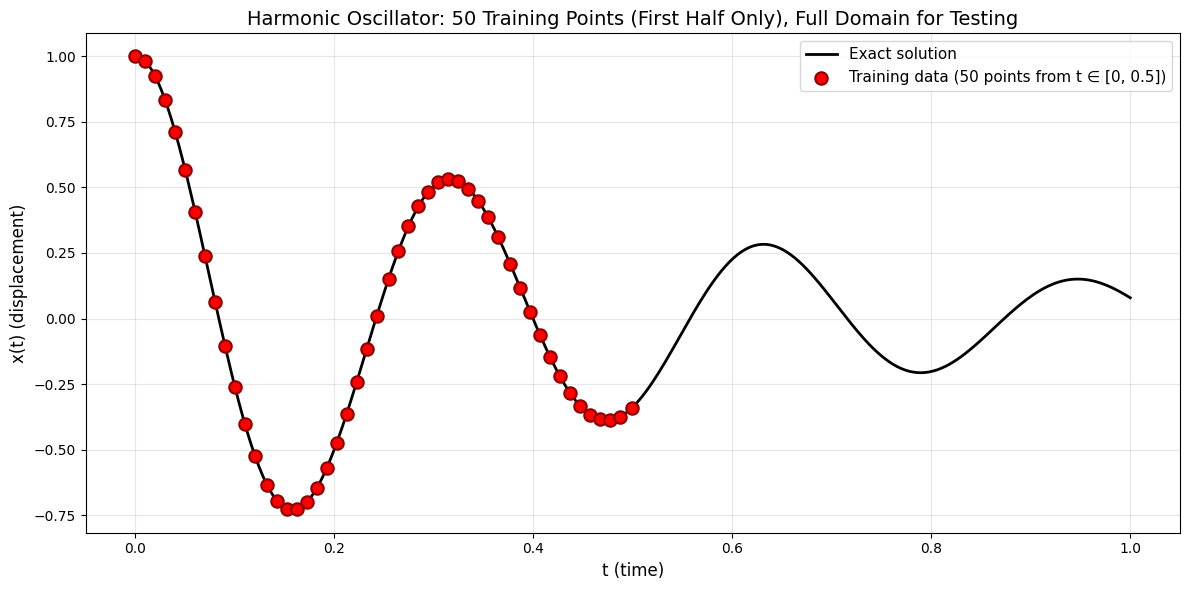


DATA PREPARATION COMPLETE
Data saved to 'harmonic_oscillator_data.pt'

Next steps:
1. Train MLP on these 50 points and evaluate on full domain
2. Train GAN on these 50 points and evaluate on full domain
3. Compare results and discuss limitations

SAVED DATA STRUCTURE
The saved file 'harmonic_oscillator_data.pt' contains:
  - t_full: Full domain time points [500, 1] (for testing)
  - x_full: Exact solution at full domain [500, 1] (for testing)
  - t_train: Training time points [50, 1]
  - x_train: Training solution values [50, 1]
  - real_data_gan: Combined (t, x) for GAN [50, 2]
  - d, w0: Physical parameters
  - n_train: Number of training points (50)


In [3]:
"""
Exercise: Modeling a Harmonic Oscillator with MLP and GAN
Course: Deep Learning

This code demonstrates the limitations of standard neural networks (MLP and GAN)
when trained on limited data from the first half of the domain [0, 0.5],
and then tested on the full domain [0, 1].

Both models receive the SAME 50 training points for fair comparison.
"""

import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Analytical solution of the harmonic oscillator
# ============================================

def oscillator(d, w0, t):
    """
    Exact solution for 1D underdamped harmonic oscillator.
    
    Parameters:
    d (float): Damping coefficient (delta)
    w0 (float): Natural frequency (omega_0)
    t (torch.Tensor): Time points
    
    Returns:
    torch.Tensor: Exact solution x(t)
    """
    assert d < w0, "Underdamped condition requires d < w0"
    w = np.sqrt(w0**2 - d**2)
    phi = np.arctan(-d / w)
    A = 1 / (2 * np.cos(phi))
    return torch.exp(-d * t) * 2 * A * torch.cos(phi + w * t)


# ============================================
# Problem parameters
# ============================================

d = 2.0      # Damping coefficient (delta)
w0 = 20.0    # Natural frequency (omega_0)

# Full domain [0, 1] for evaluation (500 points)
t_full = torch.linspace(0, 1, 500).view(-1, 1)
x_full = oscillator(d, w0, t_full).view(-1, 1)

# First half domain [0, 0.5] (approximately 250 points)
t_half = t_full[t_full[:, 0] <= 0.5]
x_half = x_full[:len(t_half)]

print("=" * 70)
print("HARMONIC OSCILLATOR PROBLEM")
print("=" * 70)
print(f"Parameters: delta = {d}, omega_0 = {w0}")
print(f"Full domain: t ∈ [0, 1] ({len(t_full)} points) - used for TESTING")
print(f"Training domain: t ∈ [0, 0.5] ({len(t_half)} points)")
print(f"Test domain: t ∈ (0.5, 1] ({len(t_full) - len(t_half)} points)")


# ============================================
# Training data: 50 uniformly spaced points from [0, 0.5]
# BOTH MLP and GAN use the SAME training data
# ============================================

n_train = 50  # Number of training points (same for both models)

# Select 50 uniformly spaced indices from the first half
indices_train = torch.linspace(0, len(t_half) - 1, n_train).long()

# Training data (same for both models)
t_train = t_half[indices_train]  # Shape: [50, 1]
x_train = x_half[indices_train]  # Shape: [50, 1]

# Prepare real data for GAN: pairs of (t, x)
real_data_gan = torch.cat([t_train, x_train], dim=1)  # Shape: [50, 2]

print("\n" + "-" * 70)
print(f"TRAINING DATA: {n_train} uniformly spaced points from t ∈ [0, 0.5]")
print("-" * 70)
print(f"t range: [{t_train.min().item():.3f}, {t_train.max().item():.3f}]")
print(f"x range: [{x_train.min().item():.3f}, {x_train.max().item():.3f}]")
print(f"Both MLP and GAN will use these {n_train} points for training.")
print(f"\nFirst 10 training points (t, x(t)):")
for i in range(min(10, len(t_train))):
    print(f"  {i+1:2d}: t = {t_train[i, 0].item():6.4f}, x = {x_train[i, 0].item():8.6f}")


# ============================================
# Single plot: Training data distribution
# ============================================

plt.figure(figsize=(12, 6))

# Plot exact solution over full domain
plt.plot(t_full.numpy(), x_full.numpy(), 'k-', linewidth=2, label='Exact solution')

# Plot training points (only from first half)
plt.scatter(t_train.numpy(), x_train.numpy(), color='red', s=80, marker='o', 
           edgecolors='darkred', linewidth=1.5, zorder=5,
           label=f'Training data ({n_train} points from t ∈ [0, 0.5])')

plt.xlabel('t (time)', fontsize=12)
plt.ylabel('x(t) (displacement)', fontsize=12)
plt.title(f'Harmonic Oscillator: {n_train} Training Points (First Half Only), Full Domain for Testing', fontsize=14)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================
# Save data for later use
# ============================================

# Save tensors for use in MLP and GAN training notebooks
torch.save({
    't_full': t_full,
    'x_full': x_full,
    't_train': t_train,
    'x_train': x_train,
    'real_data_gan': real_data_gan,
    'd': d,
    'w0': w0,
    'n_train': n_train
}, 'harmonic_oscillator_data.pt')

print("\n" + "=" * 70)
print("DATA PREPARATION COMPLETE")
print("=" * 70)
print("Data saved to 'harmonic_oscillator_data.pt'")
print("\nNext steps:")
print("1. Train MLP on these 50 points and evaluate on full domain")
print("2. Train GAN on these 50 points and evaluate on full domain")
print("3. Compare results and discuss limitations")
print("=" * 70)

print("\n" + "=" * 70)
print("SAVED DATA STRUCTURE")
print("=" * 70)
print("The saved file 'harmonic_oscillator_data.pt' contains:")
print("  - t_full: Full domain time points [500, 1] (for testing)")
print("  - x_full: Exact solution at full domain [500, 1] (for testing)")
print("  - t_train: Training time points [50, 1]")
print("  - x_train: Training solution values [50, 1]")
print("  - real_data_gan: Combined (t, x) for GAN [50, 2]")
print("  - d, w0: Physical parameters")
print("  - n_train: Number of training points (50)")
print("=" * 70)


---

## Task 1: MLP Model

You are given an MLP implementation. Train it **only on t_train** and then evaluate on the full domain.

### Starter MLP Code

```python
class MLP(nn.Module):
    """Simple fully connected network"""
    def __init__(self, n_input=1, n_output=1, n_hidden=32, n_layers=3):
        super().__init__()
        self.input_layer = nn.Linear(n_input, n_hidden)
        self.hidden_layers = nn.ModuleList([nn.Linear(n_hidden, n_hidden) for _ in range(n_layers - 1)])
        self.output_layer = nn.Linear(n_hidden, n_output)
        self.activation = nn.Tanh()
    
    def forward(self, x):
        x = self.activation(self.input_layer(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        return self.output_layer(x)
```

### Your Tasks (MLP)

1. Create an MLP with 3 hidden layers, 32 neurons each, Tanh activation.
2. Train it using **Adam optimizer** (learning rate = 1e-3) and **MSE loss** for **2000 epochs**.
3. Plot **training loss vs epoch**.
4. Plot the **MLP prediction on full domain** together with the exact solution and training points.
5. **Quantify error**: Compute and print MSE on training region and on the unseen test region (t > 0.5).
6. **Discuss**: Does the MLP generalize well beyond the training region? Why or why not?

---

## Task 2: GAN Model

Now implement a GAN to learn the same distribution $(t, x(t))$. The generator should produce points $(t_{\text{fake}}, x_{\text{fake}})$ that resemble the true oscillator curve.

### Starter GAN Code

```python
class Generator(nn.Module):
    def __init__(self, latent_dim=10, output_dim=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
    
    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)
```

### Data preparation for GAN

For GAN, training data should be pairs `(t, x(t))` from the **first half** of the domain.

```python
# Real training data for GAN: (t, x) pairs from first half
real_data = torch.cat([t_train, x_train], dim=1)  # shape [N, 2]
```

### Your Tasks (GAN)

1. Implement a GAN with:
   - Latent dimension = 10
   - Generator output dimension = 2 (t and x)
   - Discriminator input dimension = 2
   - Adam optimizers (lr=0.0002, betas=(0.5, 0.999))

2. Train for **15,000 epochs** (or until reasonable convergence), batch size = 32.
3. Every 1000 epochs, record generator and discriminator losses.
4. **Important constraint**: The generator must be forced to produce points with `t` in `[0, 1]`. You can apply a `torch.sigmoid` to the first output component of the generator to keep t in [0,1].

   *Hint:* Modify the generator's forward to:
   ```python
   raw = self.model(z)
   t_out = torch.sigmoid(raw[:, 0:1])  # constrain to [0,1]
   x_out = raw[:, 1:2]                 # no constraint on x
   return torch.cat([t_out, x_out], dim=1)
   ```



5. At the end of training, generate **500 fake samples** and plot them:
   - Scatter plot of fake points `(t_fake, x_fake)`
   - Overlay exact solution curve
   - Overlay real training points

6. **Quantitative evaluation**:
   - Compute MSE between fake samples and exact solution at the same t values (interpolate or use nearest neighbor).
   - Report MSE on training region (t ≤ 0.5) and test region (t > 0.5).

7. **Discuss**: How well does the GAN extrapolate beyond the training region compared to the MLP?

---

## Deliverables

Your Jupyter Notebook should contain:

1. **All code cells** (run and with visible outputs)
2. **Plots** for:
   - MLP loss curve
   - MLP prediction vs exact solution
   - GAN loss curves (generator and discriminator)
   - GAN-generated samples vs exact solution
3. **Printed error metrics** (MSE on train/test regions for both models)
4. **Discussion / short answers** for:
   - Why does the MLP fail (or succeed) outside the training region?
   - Why does the GAN behave differently? Does it "imagine" plausible solutions?
   - Which model gives better extrapolation? Why?

---

## Evaluation Criteria

| Criteria | Weight |
|----------|--------|
| Correct implementation of MLP training | 20% |
| Correct implementation of GAN training | 30% |
| Quality of plots and visualizations | 20% |
| Quantitative error reporting | 10% |
| Discussion and analysis | 20% |

---

Good luck, and enjoy exploring the limits of standard neural networks!